# Convolutional VAE on CIFAR10

Same VAE idea as before (encoder → latent distribution → sampled `z` → decoder, trained with reconstruction loss + KL divergence), but adapted to CIFAR10's 3x32x32 RGB images: the fully-connected encoder/decoder are replaced with **convolutional** and **transposed convolutional** layers, which are much better suited to image data since they preserve spatial structure and share weights across the image.

In [1]:
import os

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torchvision.utils import save_image
import matplotlib.pyplot as plt

In [ ]:
DATA_DIR = os.path.join("..", "data")

In [2]:
# Check if MPS is available
device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Using device: {device}")

Using device: mps


In [3]:
def to_img(x):
    x = 0.5*(x+1)
    x = x.clamp(0, 1)
    x = x.view(x.size(0), 3, 32, 32)
    return x

img_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]
)

In [4]:
#hyperparams
num_epochs = 50
batch_size = 128
lr = 1e-3
latent_dim = 128

In [ ]:
# dataset (CIFAR10) - reuses DATA_DIR if already downloaded, otherwise fetches it there
dataset = CIFAR10(DATA_DIR, transform=img_transform, download=True)
dataloader = DataLoader(dataset, batch_size, shuffle=True)

In [7]:
if not os.path.exists('./cvae_img'):
    os.mkdir('./cvae_img')

## Model

A convolutional VAE for CIFAR10 (3x32x32 RGB images).

**Encoder**: 3 strided convolutions downsample `32x32 → 16x16 → 8x8 → 4x4` while increasing channels `3 → 32 → 64 → 128`, then a flatten + two linear heads produce `mu` and `logvar` for the `latent_dim`-sized latent space.

**Decoder**: a linear layer projects `z` back to a `128x4x4` feature map, then 3 transposed convolutions upsample back to `32x32x3`, with a final `Tanh` to match the `[-1, 1]` normalized pixel range.

In [8]:
# Model
class ConvVAE(nn.Module):
    def __init__(self, latent_dim: int):
        """Convolutional VAE for 3x32x32 images (e.g. CIFAR10)."""
        super(ConvVAE, self).__init__()

        # Encoder: 32x32 -> 16x16 -> 8x8 -> 4x4
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
        )
        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

        # Decoder: 4x4 -> 8x8 -> 16x16 -> 32x32
        self.fc_decode = nn.Linear(latent_dim, 128 * 4 * 4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Map an image batch to the latent distribution parameters (mu, logvar)."""
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparametrize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        """Sample z ~ N(mu, sigma^2) in a differentiable way (reparameterization trick)."""
        std = logvar.mul(0.5).exp_()
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mu)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Map a latent vector z back to a reconstructed image."""
        h = self.fc_decode(z)
        h = h.view(h.size(0), 128, 4, 4)
        return self.decoder(h)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        return self.decode(z), mu, logvar

In [9]:
# Instance of the model
model = ConvVAE(latent_dim).to(device)

# reconstruction loss
reconstruction_loss = nn.MSELoss(reduction='sum')

# reconstruction + KL divergence
def loss_function(recon_x: torch.Tensor, x: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    """Compute VAE loss as reconstruction error + KL divergence to a standard normal prior."""
    recon_loss = reconstruction_loss(recon_x, x)

    kl_element = mu.pow(2).add_(logvar.exp()).mul_(-1).add_(1).add_(logvar)
    kl = torch.sum(kl_element).mul_(-0.5)

    return recon_loss + kl


#optimizer
optimizer = optim.Adam(model.parameters(), lr)

## Training

Run each image batch through the conv VAE and minimize reconstruction loss + KL divergence. Every 10 epochs a sample reconstruction is saved to `./cvae_img/`.

In [10]:
# Training
for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for batch_idx, data in enumerate(dataloader):
        img, _ = data
        img = img.to(device)

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(img)
        loss = loss_function(recon_batch, img, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

        if batch_idx % 10 == 0:
            print("Train Epoch: {} [{}/{}] ({:.0f}%]\tLoss: {:.6f}".format(
                epoch,
                batch_idx * len(img),
                len(dataloader.dataset), 100. * batch_idx / len(dataloader),
                loss.item() / len(img)
            ))

    print("====> Epoch: {} Average Loss: {:.4f}".format(
        epoch, train_loss / len(dataloader.dataset)
    ))

    if epoch % 10 == 0:
        save = to_img(recon_batch.cpu().data)
        save_image(save, './cvae_img/image_{}.png'.format(epoch))

torch.save(model.state_dict(), './cvae_cifar10.pth')

Train Epoch: 0 [0/50000] (0%]	Loss: 1487.103760
Train Epoch: 0 [1280/50000] (3%]	Loss: 633.533020
Train Epoch: 0 [2560/50000] (5%]	Loss: 466.509949
Train Epoch: 0 [3840/50000] (8%]	Loss: 434.801971
Train Epoch: 0 [5120/50000] (10%]	Loss: 388.926758
Train Epoch: 0 [6400/50000] (13%]	Loss: 362.496643
Train Epoch: 0 [7680/50000] (15%]	Loss: 359.141876
Train Epoch: 0 [8960/50000] (18%]	Loss: 359.089508
Train Epoch: 0 [10240/50000] (20%]	Loss: 336.700348
Train Epoch: 0 [11520/50000] (23%]	Loss: 331.158661
Train Epoch: 0 [12800/50000] (26%]	Loss: 335.662842
Train Epoch: 0 [14080/50000] (28%]	Loss: 312.909515
Train Epoch: 0 [15360/50000] (31%]	Loss: 301.454132
Train Epoch: 0 [16640/50000] (33%]	Loss: 313.366669
Train Epoch: 0 [17920/50000] (36%]	Loss: 293.529297
Train Epoch: 0 [19200/50000] (38%]	Loss: 288.604279
Train Epoch: 0 [20480/50000] (41%]	Loss: 289.169678
Train Epoch: 0 [21760/50000] (43%]	Loss: 279.007019
Train Epoch: 0 [23040/50000] (46%]	Loss: 274.437439
Train Epoch: 0 [24320/5000

## Evaluation

Run the trained conv VAE on the CIFAR10 test set and visually compare original vs. reconstructed images.

In [ ]:
# test dataset
test_data = CIFAR10(DATA_DIR, transform=img_transform, download=True, train=False)
test_dataloader = DataLoader(test_data, batch_size, shuffle=False)

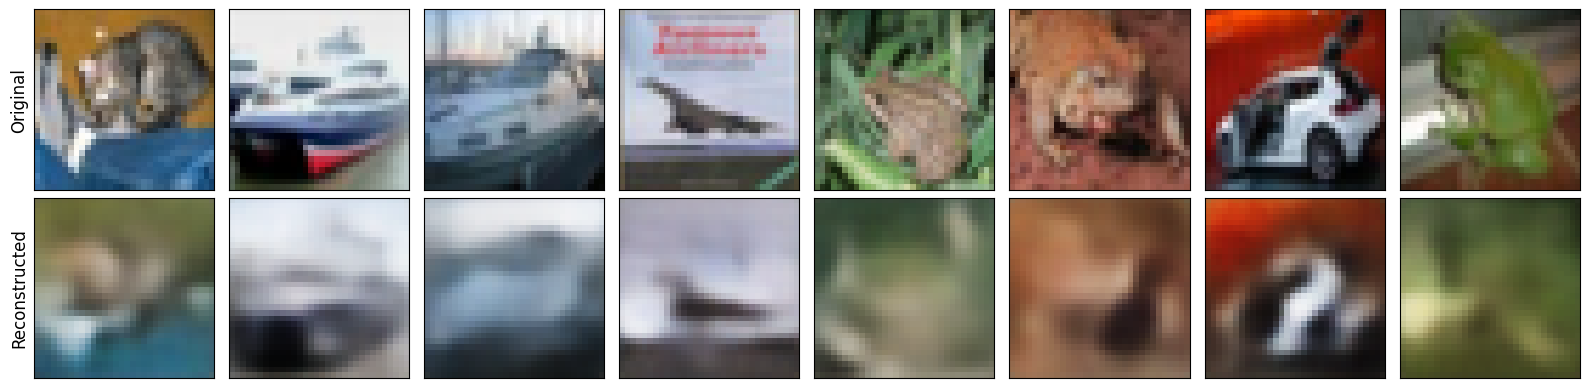

In [14]:
num_examples = 8

model.eval()
with torch.no_grad():
    for data in test_dataloader:
        img, _ = data
        img = img.to(device)

        output, mu, logvar = model(img)
        output = output.detach()

        originals = to_img(img)[:num_examples].cpu().permute(0, 2, 3, 1)
        reconstructions = to_img(output)[:num_examples].cpu().permute(0, 2, 3, 1)

        fig, axes = plt.subplots(2, num_examples, figsize=(2 * num_examples, 4))
        for i in range(num_examples):
            axes[0, i].imshow(originals[i])
            axes[0, i].set_xticks([])
            axes[0, i].set_yticks([])
            axes[1, i].imshow(reconstructions[i])
            axes[1, i].set_xticks([])
            axes[1, i].set_yticks([])

        axes[0, 0].set_ylabel("Original", fontsize=12)
        axes[1, 0].set_ylabel("Reconstructed", fontsize=12)
        plt.tight_layout()
        break